<a href="https://colab.research.google.com/github/belokonr/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/hw5/HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

In [32]:
import wbgapi as wb
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, lasso_path, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve, f1_score, precision_score, recall_score
)
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
import math

In [33]:
# ============================================================
# PART 1A: Download World Bank Data
# ============================================================

# WDI indicator codes for our predictors
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),  # 2013–2019
        skipBlanks=True,
        labels=False
    )
    raw_data.columns = [INDICATORS[c] if c in INDICATORS else c for c in raw_data.columns]
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7211, 7)
Download successful ✓


In [34]:
# ============================================================
# PART 1B: Build the Analysis Dataset
# ============================================================

# Average over time dimension
if isinstance(raw_data.index, pd.MultiIndex):
    averaged_by_series = raw_data.mean(axis=1)
    country_data = averaged_by_series.unstack(level='series')
    country_data = country_data.rename(columns=INDICATORS)
else:
    country_data = raw_data.copy()

# Drop countries with too many missing values (keep countries with >= 60% non-missing)
threshold = 0.60
country_data = country_data.dropna(thresh=int(threshold * country_data.shape[1]))

# Drop indicators with too many missing values across countries
country_data = country_data.dropna(axis=1, thresh=int(threshold * len(country_data)))

# Final fill: impute remaining missing values with the cross-country median
country_data = country_data.fillna(country_data.median())

print(f"Final dataset: {len(country_data)} countries × {country_data.shape[1]} indicators")
print(f"\nSample countries: {list(country_data.index[:5])}")
print(f"\nIndicators retained: {list(country_data.columns)}")
print(f"\nGDP growth summary:")
print(country_data[OUTCOME_VAR].describe().round(2))

Final dataset: 238 countries × 29 indicators

Sample countries: ['ABW', 'AFE', 'AFG', 'AFW', 'AGO']

Indicators retained: ['arable_land_pct', 'current_account_pct_gdp', 'royalties_receipts', 'fdi_inflows_pct_gdp', 'electricity_access_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'real_interest_rate', 'govt_expenditure_pct_gdp', 'mobile_subscriptions_per100', 'internet_users_pct', 'trade_pct_gdp', 'agriculture_pct_gdp', 'gdp_growth_pc', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'secondary_enrollment_gross', 'tertiary_enrollment_gross', 'education_expenditure_pct_gdp', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'life_expectancy', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']

GDP growth summary:
count    238.00
mean       1.76
std        2.45
min      -12.55
25%        0.57
50%        1.80
75%        3.30
max        7.39
Name: gdp_growth_pc, dtype: float64

In [35]:
# ============================================================
# PART 1C: Train-Test Split & OLS Baseline
# ============================================================

# Separate outcome (y) from predictors (X)
feature_cols = [c for c in country_data.columns if c != OUTCOME_VAR]

X = country_data[feature_cols].values
y = country_data[OUTCOME_VAR].values
feature_names = feature_cols

# 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"Training countries: {X_train.shape[0]}")
print(f"Test countries: {X_test.shape[0]}")
print(f"Number of predictors: {X_train.shape[1]}")
print(f"Predictor-to-observation ratio (train): p/n = {X_train.shape[1]}/{X_train.shape[0]} = {X_train.shape[1]/X_train.shape[0]:.2f}")
print()
print("If p/n > 0.5, OLS is at serious risk of overfitting.")

# Standardize features (critical for Ridge and Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # apply same transform to test

print("\nFeatures standardized (zero mean, unit variance) ✓")

Training countries: 166
Test countries: 72
Number of predictors: 28
Predictor-to-observation ratio (train): p/n = 28/166 = 0.17

If p/n > 0.5, OLS is at serious risk of overfitting.

Features standardized (zero mean, unit variance) ✓


In [36]:
# ============================================================
# PART 1.1: OLS Baseline — Demonstrating the Failure Mode
# ============================================================

ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

# Training performance
y_train_pred_ols = ols_model.predict(X_train_scaled)
ols_train_r2  = r2_score(y_train, y_train_pred_ols)
ols_train_mse = mean_squared_error(y_train, y_train_pred_ols)

# Test performance
y_test_pred_ols = ols_model.predict(X_test_scaled)
ols_test_r2  = r2_score(y_test, y_test_pred_ols)
ols_test_mse = mean_squared_error(y_test, y_test_pred_ols)

print("=" * 45)
print("OLS BASELINE RESULTS")
print("=" * 45)
print(f"Training R²:  {ols_train_r2:.3f}")
print(f"Test R²:      {ols_test_r2:.3f}")
print(f"")
print(f"Training MSE: {ols_train_mse:.3f}")
print(f"Test MSE:     {ols_test_mse:.3f}")
print(f"")
print(f"Gap (Train R² - Test R²): {ols_train_r2 - ols_test_r2:.3f}")
print("=" * 45)
print()
print("Interpretation:")
print(f"  OLS fits the training data {ols_train_r2:.0%} — but only explains")
print(f"  {max(ols_test_r2, 0):.0%} of test variance. This is overfitting.")

OLS BASELINE RESULTS
Training R²:  0.603
Test R²:      -0.914

Training MSE: 2.615
Test MSE:     8.542

Gap (Train R² - Test R²): 1.517

Interpretation:
  OLS fits the training data 60% — but only explains
  0% of test variance. This is overfitting.


In [37]:
p = X_train.shape[1]  # Number of predictors (columns)
n = X_train.shape[0]  # Number of observations (rows)

pn_ratio = p / n
print(f"Predictor-to-observation ratio (p/n): {pn_ratio:.4f}")

Predictor-to-observation ratio (p/n): 0.1687


A high p/n ratio indicates many features being used in the model - a significant portion compared to how many total observations there are. With this sort of model, we get closer and closer to a model that is fully dependent on the dataset because the degrees of freedom are too high and doesn't work predictively outside of it, which is the definition of overfitting. This is a high variance, low bias model.

In [38]:
# ============================================================
# PART 1.2A: Ridge Regression with Cross-Validated Lambda
# ============================================================

# Grid of lambda (alpha) values to try — log-spaced from 0.01 to 1000
lambda_grid = np.logspace(-2, 3, 50)

# TODO: Create a RidgeCV with 5-fold CV and the lambda_grid above
ridge_cv = RidgeCV(alphas=lambda_grid, cv=5)  # ← complete this line

# TODO: Fit ridge_cv on the scaled training data
ridge_cv.fit(X_train_scaled, y_train)  # ← complete this line

# Evaluate on test set
y_test_pred_ridge = ridge_cv.predict(X_test_scaled)
ridge_test_r2  = r2_score(y_test, y_test_pred_ridge)
ridge_test_mse = mean_squared_error(y_test, y_test_pred_ridge)

print("=" * 45)
print("RIDGE REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {ridge_cv.alpha_:.4f}")
print(f"Non-zero coefficients:    {np.sum(ridge_cv.coef_ != 0)} of {X_train.shape[1]}")
print(f"Test R²:                  {ridge_test_r2:.3f}")
print(f"Test MSE:                 {ridge_test_mse:.3f}")
print()
print(f"vs. OLS: Test R² = {ols_test_r2:.3f}, Test MSE = {ols_test_mse:.3f}")

RIDGE REGRESSION RESULTS
Optimal λ* (CV-selected): 47.1487
Non-zero coefficients:    28 of 28
Test R²:                  -0.068
Test MSE:                 4.767

vs. OLS: Test R² = -0.914, Test MSE = 8.542


In [39]:
# ============================================================
# PART 1.2B: LassoCV — Automated Feature Selection
# ============================================================

def fit_lasso_cv(X_train, y_train, X_test, y_test, cv=5):
    """
    Fit LassoCV to select optimal regularization parameter
    and evaluate on test set.

    Parameters
    ----------
    X_train : np.ndarray — Standardized training features
    y_train : np.ndarray — Training outcome (GDP growth)
    X_test  : np.ndarray — Standardized test features
    y_test  : np.ndarray — Test outcome
    cv      : int — Number of cross-validation folds

    Returns
    -------
    lasso_model : LassoCV — Fitted model with optimal alpha
    test_r2     : float   — R² on held-out test set
    test_mse    : float   — MSE on held-out test set
    """
    # TODO: Create a LassoCV with cv folds and max_iter=10_000
    lasso_model = LassoCV(cv=cv, max_iter=10_000, random_state=42)

    # TODO: Fit the model on training data
    lasso_model.fit(X_train, y_train)

    # Predict on test set
    y_pred = lasso_model.predict(X_test)

    # TODO: Compute test R² and test MSE
    test_r2  = r2_score(y_test, y_pred)
    test_mse = mean_squared_error(y_test, y_pred)

    return lasso_model, test_r2, test_mse


# Call the function
lasso_cv_model, lasso_test_r2, lasso_test_mse = fit_lasso_cv(
    X_train_scaled, y_train, X_test_scaled, y_test, cv=5
)

n_nonzero = np.sum(lasso_cv_model.coef_ != 0)

print("=" * 45)
print("LASSO REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {lasso_cv_model.alpha_:.4f}")
print(f"Non-zero coefficients:    {n_nonzero} of {X_train.shape[1]}")
print(f"Test R²:                  {lasso_test_r2:.3f}")
print(f"Test MSE:                 {lasso_test_mse:.3f}")
print()
print("Selected predictors (non-zero Lasso coefficients):")
selected_features = [
    (feature_names[i], lasso_cv_model.coef_[i])
    for i in range(len(feature_names))
    if lasso_cv_model.coef_[i] != 0
]
for name, coef in sorted(selected_features, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:<40} coef = {coef:+.4f}")

LASSO REGRESSION RESULTS
Optimal λ* (CV-selected): 0.0660
Non-zero coefficients:    18 of 28
Test R²:                  -0.355
Test MSE:                 6.048

Selected predictors (non-zero Lasso coefficients):
  inflation_cpi                            coef = -1.0351
  population_growth                        coef = -0.7708
  natural_resource_rents_pct_gdp           coef = -0.6392
  infant_mortality_per1000                 coef = -0.4314
  health_expenditure_pct_gdp               coef = -0.3914
  atms_per100k                             coef = -0.3877
  unemployment_rate                        coef = -0.3792
  renewable_energy_pct                     coef = +0.3721
  urbanization_pct                         coef = -0.3694
  exchange_rate_official                   coef = +0.3078
  arable_land_pct                          coef = +0.1856
  mobile_subscriptions_per100              coef = +0.0846
  tertiary_enrollment_gross                coef = -0.0757
  trade_pct_gdp                     

In [40]:
# ============================================================
# PART 1.2C: Model Comparison Table
# ============================================================

comparison = pd.DataFrame({
    'Method': ['OLS', 'Ridge (RidgeCV)', 'Lasso (LassoCV)'],
    'Lambda (α*)': [
        'N/A (no penalty)',
        f'{ridge_cv.alpha_:.4f}',
        f'{lasso_cv_model.alpha_:.4f}'
    ],
    'Non-zero Predictors': [
        X_train.shape[1],
        X_train.shape[1],
        np.sum(lasso_cv_model.coef_ != 0)
    ],
    'Training R²': [
        f'{r2_score(y_train, ols_model.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, ridge_cv.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, lasso_cv_model.predict(X_train_scaled)):.3f}'
    ],
    'Test R²': [
        f'{ols_test_r2:.3f}',
        f'{ridge_test_r2:.3f}',
        f'{lasso_test_r2:.3f}'
    ],
    'Test MSE': [
        f'{ols_test_mse:.3f}',
        f'{ridge_test_mse:.3f}',
        f'{lasso_test_mse:.3f}'
    ]
})

print(comparison.to_string(index=False))
print()
print("Key observations:")
print(f"  • OLS training R² >> test R²: evidence of overfitting (high variance)")
print(f"  • Ridge and Lasso reduce the train-test gap")
print(f"  • Lasso selects only {np.sum(lasso_cv_model.coef_ != 0)} of {X_train.shape[1]} predictors")
print(f"  • The other {X_train.shape[1] - np.sum(lasso_cv_model.coef_ != 0)} are predictively redundant,")
print(f"    not necessarily economically unimportant")

         Method      Lambda (α*)  Non-zero Predictors Training R² Test R² Test MSE
            OLS N/A (no penalty)                   28       0.603  -0.914    8.542
Ridge (RidgeCV)          47.1487                   28       0.559  -0.068    4.767
Lasso (LassoCV)           0.0660                   18       0.573  -0.355    6.048

Key observations:
  • OLS training R² >> test R²: evidence of overfitting (high variance)
  • Ridge and Lasso reduce the train-test gap
  • Lasso selects only 18 of 28 predictors
  • The other 10 are predictively redundant,
    not necessarily economically unimportant


Ridge and Lasso both sacrifice a lower bias to get a lower variance. Both perform better than OLS on the test set in terms of R^2 and MSE, though training performance is lower. I would recommend Ridge to the IMF director because it keeps all the data intact, while Lasso removes 10 of the 28 predictors. It also performs the best on the test set.

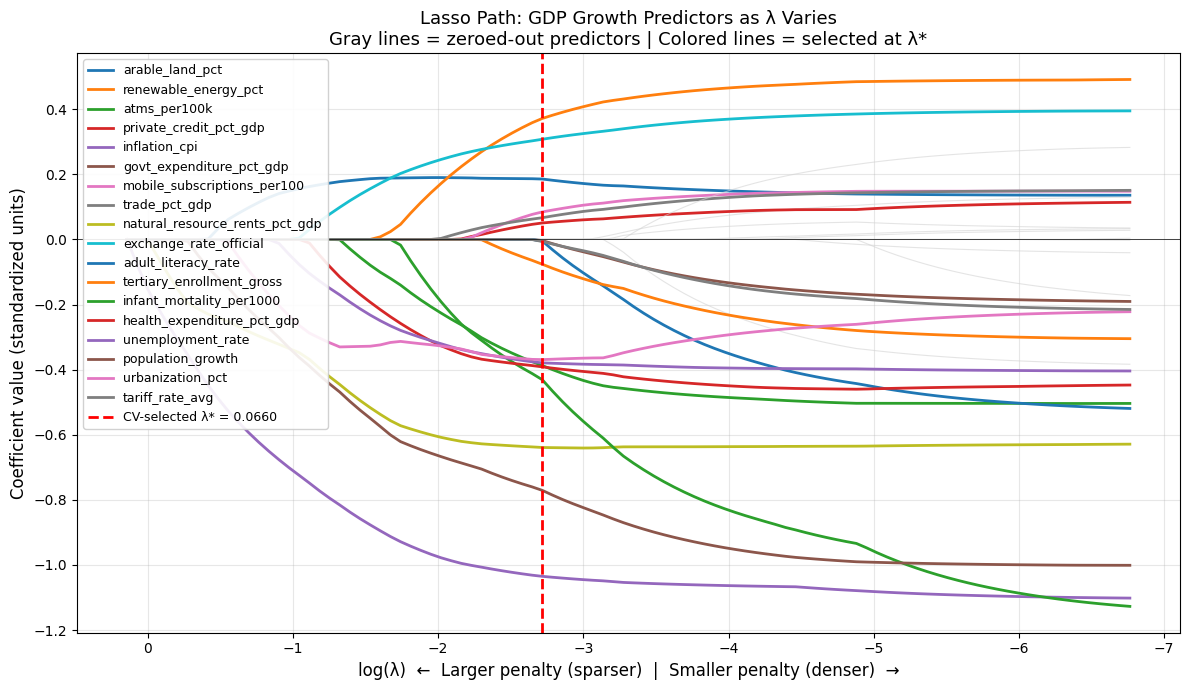

Lasso Path saved to lasso_path_gdp_growth.png


In [41]:
# ============================================================
# PART 1.3: The Lasso Path — Who Enters First?
# ============================================================

alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train,
    eps=1e-3,
    n_alphas=100,
)

optimal_alpha = lasso_cv_model.alpha_

fig, ax = plt.subplots(figsize=(12, 7))

active_features_idx = np.where(lasso_cv_model.coef_ != 0)[0]

for i in range(len(feature_names)):
    if i in active_features_idx:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=2, label=feature_names[i])
    else:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=0.8, color='lightgray', alpha=0.6)

ax.axvline(np.log(optimal_alpha), color='red', linestyle='--', linewidth=2,
           label=f'CV-selected λ* = {optimal_alpha:.4f}')
ax.axhline(0, color='black', linewidth=0.5)

ax.set_xlabel('log(λ)  ←  Larger penalty (sparser)  |  Smaller penalty (denser)  →',
               fontsize=12)
ax.set_ylabel('Coefficient value (standardized units)', fontsize=12)
ax.set_title(
    'Lasso Path: GDP Growth Predictors as λ Varies\n'
    'Gray lines = zeroed-out predictors | Colored lines = selected at λ*',
    fontsize=13
)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.invert_xaxis()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lasso_path_gdp_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Lasso Path saved to lasso_path_gdp_growth.png")

Unemployment rate is the first predictor to enter the model, which makes sense as it is a key economic indicator that directly impacts how much output a country can produce.

The interpretation of health being irrelevant to economic growth is incorrect because Lasso removes redundant variables, not insignificant ones. The impact that health has on GDP growth might be better covered by other variables in the dataset, but that doesn't mean it doesn't also have an effect.

In [42]:
selected_features1 = [
    (feature_names[i])
    for i in range(len(feature_names))
    if lasso_cv_model.coef_[i] != 0
]
selected_features1

['arable_land_pct',
 'renewable_energy_pct',
 'atms_per100k',
 'private_credit_pct_gdp',
 'inflation_cpi',
 'govt_expenditure_pct_gdp',
 'mobile_subscriptions_per100',
 'trade_pct_gdp',
 'natural_resource_rents_pct_gdp',
 'exchange_rate_official',
 'adult_literacy_rate',
 'tertiary_enrollment_gross',
 'infant_mortality_per1000',
 'health_expenditure_pct_gdp',
 'unemployment_rate',
 'population_growth',
 'urbanization_pct',
 'tariff_rate_avg']

In [43]:
country_data['crisis'] = np.where(country_data['gdp_growth_pc'] < 0, '1', '0')

In [44]:
# ============================================================
# PART 2.1.1: Train-Test Split & OLS Baseline
# ============================================================

# Separate outcome (y) from predictors (X)
#feature_cols = [c for c in country_data.columns if c != 'crisis' and if c != OUTCOME_VAR]

X = country_data[selected_features1].values
y = country_data['crisis'].values
feature_names = selected_features1

# 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"Training countries: {X_train.shape[0]}")
print(f"Test countries: {X_test.shape[0]}")
print(f"Number of predictors: {X_train.shape[1]}")
print(f"Predictor-to-observation ratio (train): p/n = {X_train.shape[1]}/{X_train.shape[0]} = {X_train.shape[1]/X_train.shape[0]:.2f}")
print()
print("If p/n > 0.5, OLS is at serious risk of overfitting.")

# Standardize features (critical for Ridge and Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # apply same transform to test

print("\nFeatures standardized (zero mean, unit variance) ✓")

Training countries: 166
Test countries: 72
Number of predictors: 18
Predictor-to-observation ratio (train): p/n = 18/166 = 0.11

If p/n > 0.5, OLS is at serious risk of overfitting.

Features standardized (zero mean, unit variance) ✓


In [45]:
# ============================================================
# PART 2.1: OLS Baseline — Demonstrating the Failure Mode
# ============================================================

ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

# Training performance
y_train_pred_ols = ols_model.predict(X_train_scaled)
ols_train_r2  = r2_score(y_train, y_train_pred_ols)
ols_train_mse = mean_squared_error(y_train, y_train_pred_ols)

# Test performance
y_test_pred_ols = ols_model.predict(X_test_scaled)
ols_test_r2  = r2_score(y_test, y_test_pred_ols)
ols_test_mse = mean_squared_error(y_test, y_test_pred_ols)

print("=" * 45)
print("OLS BASELINE RESULTS")
print("=" * 45)
print(f"Training R²:  {ols_train_r2:.3f}")
print(f"Test R²:      {ols_test_r2:.3f}")
print(f"")
print(f"Training MSE: {ols_train_mse:.3f}")
print(f"Test MSE:     {ols_test_mse:.3f}")
print(f"")
print(f"Gap (Train R² - Test R²): {ols_train_r2 - ols_test_r2:.3f}")
print("=" * 45)
print()
print("Interpretation:")
print(f"  OLS fits the training data {ols_train_r2:.0%} — but only explains")
print(f"  {max(ols_test_r2, 0):.0%} of test variance. This is overfitting.")


OLS BASELINE RESULTS
Training R²:  0.391
Test R²:      -0.221

Training MSE: 0.075
Test MSE:     0.191

Gap (Train R² - Test R²): 0.612

Interpretation:
  OLS fits the training data 39% — but only explains
  0% of test variance. This is overfitting.


In [46]:
count = sum(y_train_pred_ols<0) + sum(y_train_pred_ols>1)
print('count of predictions less than 0 or more than 1:', count)

count of predictions less than 0 or more than 1: 42



0-100 are the possible percentages we can interpret for probabilities. If we are getting predictions outside of this for countries, we are not getting an accurate idea of what the true likelihood of crisis is for that country. The middle values may be more accurate, but a linear fit simply doesn't offer enough flexibility for the edge cases.



In [47]:
# ============================================================
# LOGISTIC REGRESSION: Coefficient Table with Odds Ratios
# ============================================================

# Fit logistic regression on standardized training data
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Build coefficient table
coef_table = pd.DataFrame({
    'Feature': selected_features1,
    'Beta': log_reg.coef_[0],
    'Odds_Ratio': np.exp(log_reg.coef_[0])
})

# Sort by absolute beta value (strongest predictors first)
coef_table['Abs_Beta'] = coef_table['Beta'].abs()
coef_table = coef_table.sort_values('Abs_Beta', ascending=False).drop(columns='Abs_Beta')
coef_table = coef_table.reset_index(drop=True)

# Display
print("=" * 65)
print("LOGISTIC REGRESSION COEFFICIENTS & ODDS RATIOS")
print("=" * 65)
print(f"{'Feature':<40} {'Beta':>10} {'Odds Ratio':>12}")
print("-" * 65)
for _, row in coef_table.iterrows():
    print(f"{row['Feature']:<40} {row['Beta']:>10.4f} {row['Odds_Ratio']:>12.4f}")
print("-" * 65)
print(f"Intercept: {log_reg.intercept_[0]:.4f}")
print("=" * 65)


LOGISTIC REGRESSION COEFFICIENTS & ODDS RATIOS
Feature                                        Beta   Odds Ratio
-----------------------------------------------------------------
arable_land_pct                             -0.9504       0.3866
population_growth                            0.8251       2.2820
health_expenditure_pct_gdp                   0.8227       2.2766
infant_mortality_per1000                     0.7434       2.1031
natural_resource_rents_pct_gdp               0.7292       2.0735
renewable_energy_pct                        -0.6664       0.5135
tariff_rate_avg                              0.5789       1.7842
unemployment_rate                            0.5324       1.7031
inflation_cpi                                0.4941       1.6390
atms_per100k                                 0.3680       1.4449
mobile_subscriptions_per100                  0.3561       1.4278
trade_pct_gdp                               -0.3531       0.7025
adult_literacy_rate                       

In [48]:
log_reg.predict_proba(X_train)[:,1].min()
log_reg.predict_proba(X_train)[:,1].max()

np.float64(1.0)

Population growth has the highest OR. A one standard deviation increase in population growth multiplies the odds of crisis by 2.28.

Strongest predictor: population_growth


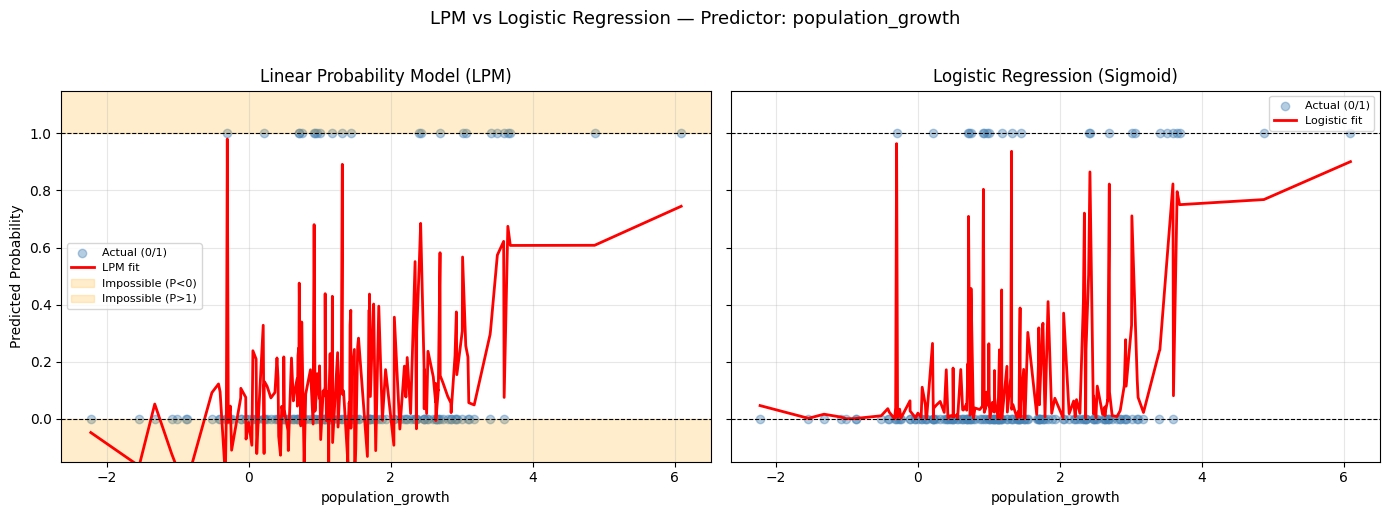

In [53]:
# ============================================================
# PART 2.2: LPM vs Logistic — Side-by-Side Comparison
# ============================================================

# Identify the strongest predictor from the odds ratio table
strongest = coef_table.iloc[1]['Feature']
strongest_idx = selected_features1.index(strongest)
print(f"Strongest predictor: {strongest}")

# Get that predictor's raw (unscaled) values for the training set
x_raw = X_train[:, strongest_idx]
y_binary = y_train.astype(int)

# LPM predictions (already computed)
lpm_preds = y_train_pred_ols.astype(float)

# Logistic predictions
log_preds = log_reg.predict_proba(X_train_scaled)[:, 1]

# Sort by the predictor for smooth curves
sort_idx = np.argsort(x_raw)
x_sorted = x_raw[sort_idx]
lpm_sorted = lpm_preds[sort_idx]
log_sorted = log_preds[sort_idx]
y_sorted = y_binary[sort_idx]

# ---- Plot ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# --- Left panel: LPM ---
ax1.scatter(x_sorted, y_sorted, alpha=0.4, color='steelblue', label='Actual (0/1)')
ax1.plot(x_sorted, lpm_sorted, color='red', linewidth=2, label='LPM fit')
ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax1.axhline(1, color='black', linestyle='--', linewidth=0.8)
# Shade impossible regions
ax1.axhspan(ymin=ax1.get_ylim()[0] if min(lpm_sorted) < 0 else -0.5,
            ymax=0, color='orange', alpha=0.2, label='Impossible (P<0)')
ax1.axhspan(ymin=1, ymax=ax1.get_ylim()[1] if max(lpm_sorted) > 1 else 1.5,
            color='orange', alpha=0.2, label='Impossible (P>1)')
ax1.set_xlabel(strongest)
ax1.set_ylabel('Predicted Probability')
ax1.set_title('Linear Probability Model (LPM)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# --- Right panel: Logistic ---
ax2.scatter(x_sorted, y_sorted, alpha=0.4, color='steelblue', label='Actual (0/1)')
ax2.plot(x_sorted, log_sorted, color='red', linewidth=2, label='Logistic fit')
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax2.axhline(1, color='black', linestyle='--', linewidth=0.8)
ax2.set_xlabel(strongest)
ax2.set_title('Logistic Regression (Sigmoid)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.15, 1.15)
ax1.set_ylim(-0.15, 1.15)

plt.suptitle(f'LPM vs Logistic Regression — Predictor: {strongest}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('lpm_vs_logistic.png', dpi=150, bbox_inches='tight')
plt.show()


In [55]:
# ============================================================
# PART 3.1: The Accuracy Paradox
# ============================================================

y_test_int = y_test.astype(int)

# --- Crisis base rate ---
base_rate = y_test_int.mean()
print(f"Crisis base rate in test set: {base_rate:.3f}  ({y_test_int.sum()} crises out of {len(y_test_int)} countries)")
print()

# --- Naïve baseline: always predict "no crisis" ---
naive_preds = np.zeros(len(y_test_int))
naive_acc = (naive_preds == y_test_int).mean()
naive_recall = recall_score(y_test_int, naive_preds, zero_division=0)

print("=" * 55)
print("NAÏVE BASELINE (always predict 'no crisis')")
print("=" * 55)
print(f"  Accuracy:        {naive_acc:.3f}")
print(f"  Recall (crisis): {naive_recall:.3f}")
print()

# --- Logistic regression at default threshold τ = 0.5 ---
log_probs = log_reg.predict_proba(X_test_scaled)[:, 1]
log_preds_50 = (log_probs >= 0.5).astype(int)
log_acc = (log_preds_50 == y_test_int).mean()
log_recall = recall_score(y_test_int, log_preds_50)

print("=" * 55)
print("LOGISTIC REGRESSION (threshold τ = 0.5)")
print("=" * 55)
print(f"  Accuracy:        {log_acc:.3f}")
print(f"  Recall (crisis): {log_recall:.3f}")
print()


Crisis base rate in test set: 0.194  (14 crises out of 72 countries)

NAÏVE BASELINE (always predict 'no crisis')
  Accuracy:        0.806
  Recall (crisis): 0.000

LOGISTIC REGRESSION (threshold τ = 0.5)
  Accuracy:        0.764
  Recall (crisis): 0.429



Because only 20% of countries experience crisis, guessing no crisis every time guarantees a 80% accuracy but catches 0 crises. The logistic regression, though it sacrifices some accuracy, catches 43% of crises, which is why only basing model decisions off of accuracy can be misleading.

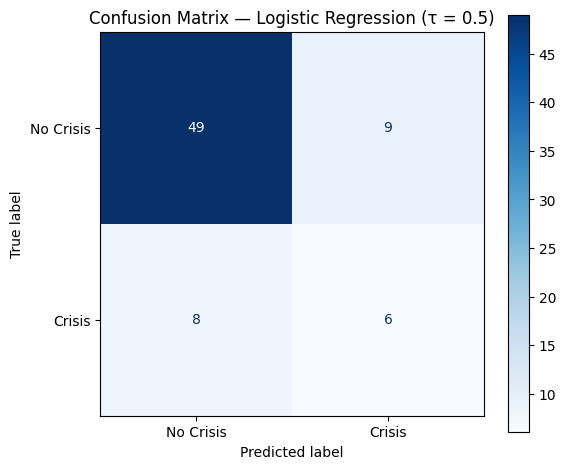

CLASSIFICATION REPORT (τ = 0.5)
              precision    recall  f1-score   support

   No Crisis       0.86      0.84      0.85        58
      Crisis       0.40      0.43      0.41        14

    accuracy                           0.76        72
   macro avg       0.63      0.64      0.63        72
weighted avg       0.77      0.76      0.77        72

CONFUSION MATRIX BREAKDOWN
  True Positives  (crises correctly flagged): 6
  False Negatives (crises missed):            8
  False Positives (false alarms):             9
  True Negatives  (non-crises correct):       49



In [56]:
# ============================================================
# PART 3.2: Confusion Matrix & Classification Report (τ = 0.5)
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix
cm = confusion_matrix(y_test_int, log_preds_50)
tn, fp, fn, tp = cm.ravel()

# --- 1. Display confusion matrix ---
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['No Crisis', 'Crisis']).plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression (τ = 0.5)')
plt.tight_layout()
plt.show()

# --- 2. Full classification report ---
print("=" * 55)
print("CLASSIFICATION REPORT (τ = 0.5)")
print("=" * 55)
print(classification_report(y_test_int, log_preds_50,
                            target_names=['No Crisis', 'Crisis']))

# --- 3. Extract individual counts ---
print("=" * 55)
print("CONFUSION MATRIX BREAKDOWN")
print("=" * 55)
print(f"  True Positives  (crises correctly flagged): {tp}")
print(f"  False Negatives (crises missed):            {fn}")
print(f"  False Positives (false alarms):             {fp}")
print(f"  True Negatives  (non-crises correct):       {tn}")
print()


False negatives are much worse from an IMF perspective than false positives. Missing a crisis leads to a 50 billion loss, while a false positive wastes only $2 million in comparison. This means recall should be prioritized, making sure we catch as many crises as possible.

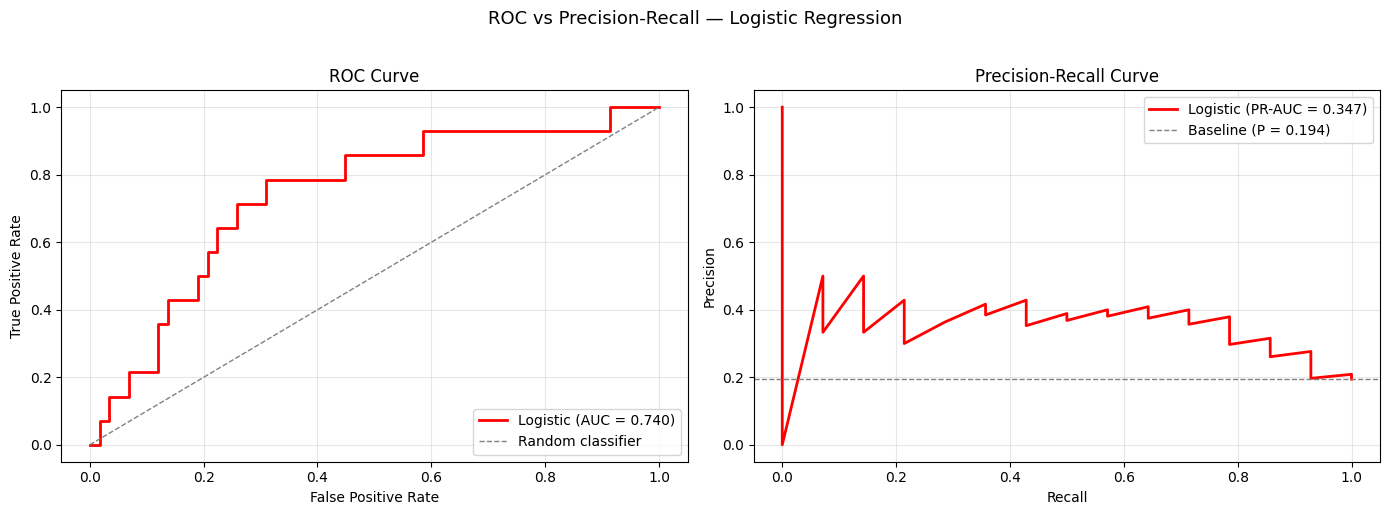

In [57]:
# ============================================================
# PART 3.3: ROC and Precision-Recall Curves
# ============================================================
from sklearn.metrics import auc

# Compute curves
fpr, tpr, _ = roc_curve(y_test_int, log_probs)
roc_auc = roc_auc_score(y_test_int, log_probs)

precision, recall, _ = precision_recall_curve(y_test_int, log_probs)
pr_auc = auc(recall, precision)

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: ROC
ax1.plot(fpr, tpr, color='red', linewidth=2, label=f'Logistic (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random classifier')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Right panel: Precision-Recall
ax2.plot(recall, precision, color='red', linewidth=2, label=f'Logistic (PR-AUC = {pr_auc:.3f})')
ax2.axhline(base_rate, color='gray', linestyle='--', linewidth=1, label=f'Baseline (P = {base_rate:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.suptitle('ROC vs Precision-Recall — Logistic Regression', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

ROC-AUC is likely higher than PR-AUC because it benefits from an abundance of True Negatives, which keeps the False Positive Rate low even if the model performs poorly on the minority class. ROC-AUC uses true negatives, whereas PR-AUC ignores them, focusing only on Precision and Recall, making PR-AUC more suitable for imbalanced datasets .

CAPACITY-CONSTRAINED THRESHOLD (≤ 5 missions)
  Threshold τ:        0.88
  Countries flagged:  5
  Precision:          0.400
  Recall:             0.143

F1-OPTIMAL THRESHOLD
  Threshold τ:        0.13
  Countries flagged:  25
  Precision:          0.400
  Recall:             0.714
  F1:                 0.513



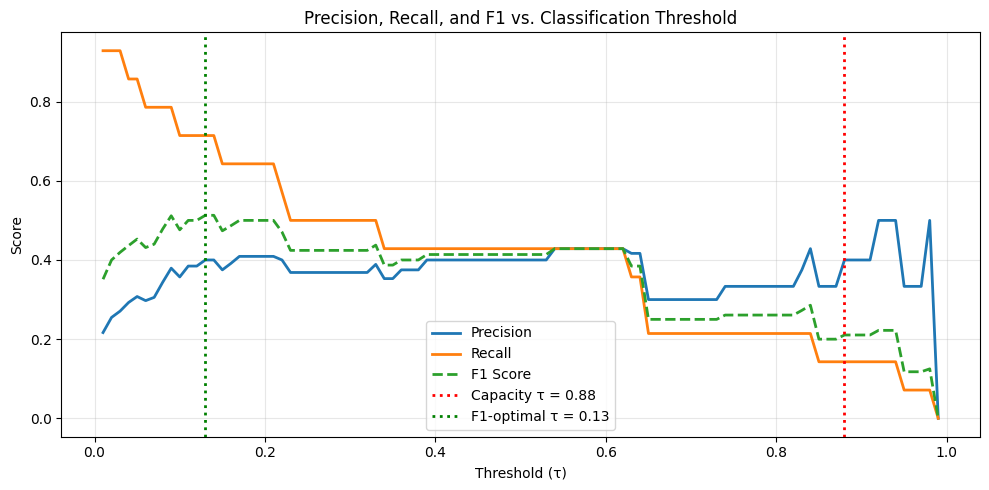

In [60]:
# ============================================================
# PART 3.4: Threshold Analysis — The 5-Mission Constraint
# ============================================================

thresholds = np.arange(0.01, 1.00, 0.01)
n_flagged = []
precisions = []
recalls = []
f1s = []

for t in thresholds:
    preds = (log_probs >= t).astype(int)
    n_flag = preds.sum()
    n_flagged.append(n_flag)
    precisions.append(precision_score(y_test_int, preds, zero_division=0))
    recalls.append(recall_score(y_test_int, preds, zero_division=0))
    f1s.append(f1_score(y_test_int, preds, zero_division=0))

n_flagged = np.array(n_flagged)
precisions = np.array(precisions)
recalls = np.array(recalls)
f1s = np.array(f1s)

# --- 1. Capacity-constrained threshold (≤ 5 flagged) ---
mask = n_flagged <= 5
tau_cap = thresholds[mask][0]  # lowest τ that satisfies the constraint
idx_cap = np.where(thresholds == tau_cap)[0][0]

print("=" * 60)
print("CAPACITY-CONSTRAINED THRESHOLD (≤ 5 missions)")
print("=" * 60)
print(f"  Threshold τ:        {tau_cap:.2f}")
print(f"  Countries flagged:  {n_flagged[idx_cap]}")
print(f"  Precision:          {precisions[idx_cap]:.3f}")
print(f"  Recall:             {recalls[idx_cap]:.3f}")
print()

# --- 2. F1-optimal threshold ---
idx_f1 = np.argmax(f1s)
tau_f1 = thresholds[idx_f1]

print("=" * 60)
print("F1-OPTIMAL THRESHOLD")
print("=" * 60)
print(f"  Threshold τ:        {tau_f1:.2f}")
print(f"  Countries flagged:  {n_flagged[idx_f1]}")
print(f"  Precision:          {precisions[idx_f1]:.3f}")
print(f"  Recall:             {recalls[idx_f1]:.3f}")
print(f"  F1:                 {f1s[idx_f1]:.3f}")
print()

# --- 3. Plot ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions, label='Precision', linewidth=2)
ax.plot(thresholds, recalls, label='Recall', linewidth=2)
ax.plot(thresholds, f1s, label='F1 Score', linewidth=2, linestyle='--')
ax.axvline(tau_cap, color='red', linestyle=':', linewidth=2,
           label=f'Capacity τ = {tau_cap:.2f}')
ax.axvline(tau_f1, color='green', linestyle=':', linewidth=2,
           label=f'F1-optimal τ = {tau_f1:.2f}')
ax.set_xlabel('Threshold (τ)')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, and F1 vs. Classification Threshold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Based on results, I would recommend a threshold at 0.8 or higher, as it would predict the most high-risk of crisis countries with high recall, and flags a reasonable amount of countries compared to the limit of 5 that the IMF can study. Of 14 crises in this data, this model catches 5 of the most high-risk.

PRIME Prompt:
Persona: You are a senior econometrician advising the IMF's
  Early Warning Division on variable-selection stability.

Role: Write a self-contained Python script that assesses how
  robust Lasso feature selection is to sample perturbation
  using bootstrap resampling.

Instructions:
  1. Accept pre-existing numpy arrays X_train_scaled (n × p)
     and y_train (n,), plus a list feature_names (length p).
  2. Draw 200 bootstrap resamples (with replacement) of size n.
  3. For each resample, fit sklearn LassoCV (5-fold, max_iter=10000,
     random_state=42) and record which features receive non-zero
     coefficients.
  4. Compute each predictor's selection frequency (fraction of 200
     resamples where its coefficient ≠ 0).
  5. Produce a horizontal bar chart: predictors on the y-axis sorted
     by selection frequency, frequency on the x-axis, with a red
     dashed vertical line at 50%. Title the chart
     "Bootstrap Lasso Selection Frequency (200 resamples)".

Methodology: Use numpy for resampling (np.random.choice with
  replace=True), sklearn.linear_model.LassoCV for fitting.
  Suppress convergence warnings with warnings.filterwarnings.

Execution: The script should run in a Jupyter notebook where
  X_train_scaled, y_train, feature_names, np, plt, and sklearn
  are already imported. Print a progress update every 50 resamples.


  Completed 50/200 resamples
  Completed 100/200 resamples
  Completed 150/200 resamples
  Completed 200/200 resamples


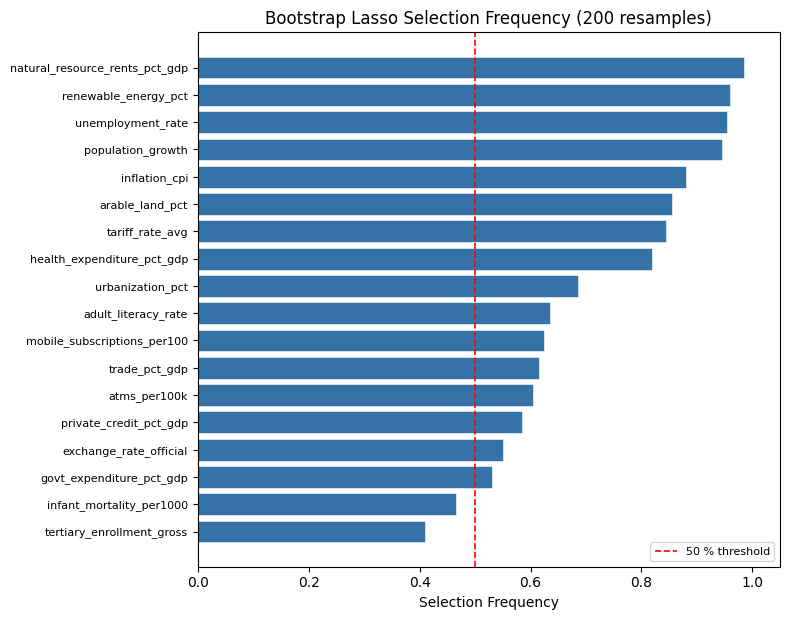


 Predictor                  Freq
 ──────────────────────────────────────
 natural_resource_rents_pct_gdp 0.98  ███████████████████
 renewable_energy_pct       0.96  ███████████████████
 unemployment_rate          0.95  ███████████████████
 population_growth          0.94  ██████████████████
 inflation_cpi              0.88  █████████████████
 arable_land_pct            0.85  █████████████████
 tariff_rate_avg            0.84  ████████████████
 health_expenditure_pct_gdp 0.82  ████████████████
 urbanization_pct           0.69  █████████████
 adult_literacy_rate        0.64  ████████████
 mobile_subscriptions_per100 0.62  ████████████
 trade_pct_gdp              0.61  ████████████
 atms_per100k               0.60  ████████████
 private_credit_pct_gdp     0.58  ███████████
 exchange_rate_official     0.55  ███████████
 govt_expenditure_pct_gdp   0.53  ██████████
 infant_mortality_per1000   0.47  █████████
 tertiary_enrollment_gross  0.41  ████████


In [64]:
import warnings
import numpy as np
from sklearn.linear_model import LassoCV

# ── Bootstrap Lasso stability assessment ──────────────────────────
n, p = X_train_scaled.shape
B = 200
selection_counts = np.zeros(p)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning if 'ConvergenceWarning' in dir() else UserWarning)

try:
    from sklearn.exceptions import ConvergenceWarning
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
except ImportError:
    pass

for b in range(B):
    idx = np.random.choice(n, size=n, replace=True)
    X_b, y_b = X_train_scaled[idx], y_train[idx]

    lasso = LassoCV(cv=5, max_iter=10_000, random_state=42)
    lasso.fit(X_b, y_b)

    selection_counts += (lasso.coef_ != 0).astype(int)

    if (b + 1) % 50 == 0:
        print(f"  Completed {b + 1}/{B} resamples")

selection_freq = selection_counts / B

# ── Horizontal bar chart ──────────────────────────────────────────
order = np.argsort(selection_freq)
sorted_names = np.array(feature_names)[order]
sorted_freq = selection_freq[order]

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * p)))
ax.barh(range(p), sorted_freq, color="#3572A5", edgecolor="white", linewidth=0.4)
ax.axvline(0.50, color="red", linestyle="--", linewidth=1.2, label="50 % threshold")
ax.set_yticks(range(p))
ax.set_yticklabels(sorted_names, fontsize=8)
ax.set_xlabel("Selection Frequency")
ax.set_title("Bootstrap Lasso Selection Frequency (200 resamples)")
ax.legend(loc="lower right", fontsize=8)
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────
print("\n Predictor                  Freq")
print(" " + "─" * 38)
for name, freq in zip(sorted_names[::-1], sorted_freq[::-1]):
    bar = "█" * int(freq * 20)
    print(f" {name:<26s} {freq:.2f}  {bar}")

8 predictors are stable and none are fragile. This means all the variables have clear relationships with the variable of interest, and there is not too much overlap between predictors as there would be for fragile ones.

PRIME Prompt:

Persona: You are a quantitative risk analyst at the IMF tasked
  with minimizing the expected financial cost of crisis
  misclassification across member states.

Role: Write a self-contained Python script that finds the
  classification threshold minimizing total expected dollar cost,
  given asymmetric misclassification costs.

Instructions:
  1. Accept pre-existing arrays y_test_int (true 0/1 labels) and
     log_probs (predicted probabilities from logistic regression),
     both already defined in the notebook.
  2. Define cost constants: cost_fn = 50e9 ($50 billion per missed
     crisis) and cost_fp = 2e6 ($2 million per false alarm).
  3. Sweep thresholds from 0.01 to 0.99 in steps of 0.01. At each
     threshold τ, classify countries as crisis if predicted
     probability ≥ τ, compute FP and FN counts from the confusion
     matrix, and calculate total_cost = FN * cost_fn + FP * cost_fp.
  4. Plot total expected cost (y-axis, in billions) vs. threshold
     (x-axis). Annotate the cost-minimizing threshold with a red
     vertical dashed line and a text label showing τ* and its cost.
  5. Print τ*, its cost, and the Precision/Recall at that point.

Methodology: Use numpy for vectorized threshold sweeps and
  sklearn.metrics for precision_score and recall_score. Convert
  costs to billions for readable y-axis labels.

Execution: The script runs in a Jupyter notebook where numpy (np),
  matplotlib.pyplot (plt), sklearn.metrics, y_test_int, and
  log_probs are already available. Also assume tau_cap, tau_f1,
  idx_cap, and idx_f1 are in scope.

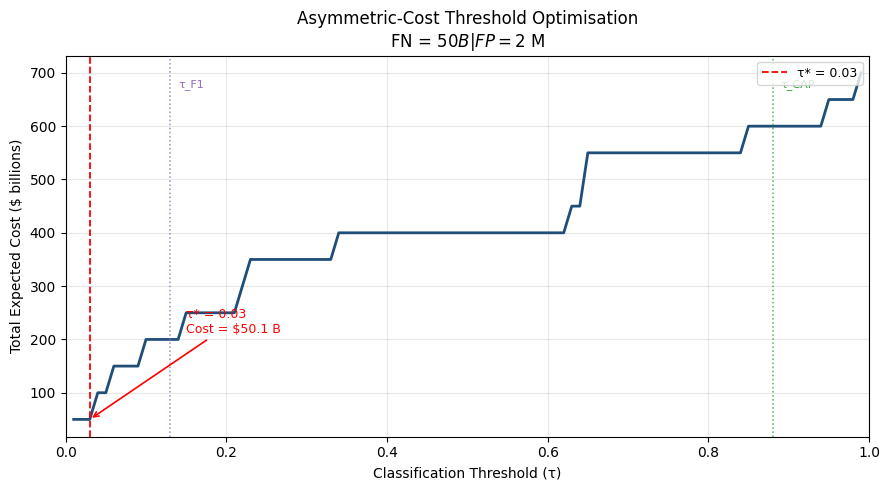


══════════════════════════════════════════════════
  Cost-minimising threshold  τ* = 0.03
  Minimum expected cost         = $50.07 B
  FN at τ* =   1   →  missed crises
  FP at τ* =  35   →  false alarms
  Precision = 0.271   Recall = 0.929
══════════════════════════════════════════════════


In [65]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix

# ── Cost constants ────────────────────────────────────────────────
cost_fn = 50e9   # $50 B per missed crisis  (false negative)
cost_fp = 2e6    # $2 M per false alarm      (false positive)

# ── Threshold sweep ───────────────────────────────────────────────
thresholds = np.arange(0.01, 1.00, 0.01)
total_costs = np.empty_like(thresholds)
fn_counts = np.empty_like(thresholds, dtype=int)
fp_counts = np.empty_like(thresholds, dtype=int)

for i, tau in enumerate(thresholds):
    y_pred = (log_probs >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_int, y_pred, labels=[0, 1]).ravel()
    fn_counts[i] = fn
    fp_counts[i] = fp
    total_costs[i] = fn * cost_fn + fp * cost_fp

# ── Optimal threshold ────────────────────────────────────────────
best_idx = np.argmin(total_costs)
tau_star = thresholds[best_idx]
min_cost = total_costs[best_idx]

y_pred_star = (log_probs >= tau_star).astype(int)
prec_star = precision_score(y_test_int, y_pred_star, zero_division=0)
rec_star  = recall_score(y_test_int, y_pred_star, zero_division=0)

# ── Cost curve plot ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, total_costs / 1e9, color="#1f4e79", linewidth=2)

ax.axvline(tau_star, color="red", linestyle="--", linewidth=1.3, label=f"τ* = {tau_star:.2f}")
ax.annotate(
    f"τ* = {tau_star:.2f}\nCost = ${min_cost/1e9:.1f} B",
    xy=(tau_star, min_cost / 1e9),
    xytext=(tau_star + 0.12, min_cost / 1e9 + (total_costs.max() - total_costs.min()) / 1e9 * 0.25),
    fontsize=9, color="red",
    arrowprops=dict(arrowstyle="->", color="red", lw=1.2),
)

# Mark CAP and F1 thresholds if available
for label, tau_ref, color in [("τ_CAP", tau_cap, "#2ca02c"), ("τ_F1", tau_f1, "#9467bd")]:
    try:
        ax.axvline(tau_ref, color=color, linestyle=":", linewidth=1.1, alpha=0.8)
        ax.text(tau_ref + 0.01, ax.get_ylim()[1] * 0.92, label, color=color, fontsize=8)
    except NameError:
        pass

ax.set_xlabel("Classification Threshold (τ)")
ax.set_ylabel("Total Expected Cost ($ billions)")
ax.set_title("Asymmetric-Cost Threshold Optimisation\n"
             f"FN = ${cost_fn/1e9:.0f} B  |  FP = ${cost_fp/1e6:.0f} M")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim(0, 1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Summary ──────────────────────────────────────────────────────
print(f"\n{'═'*50}")
print(f"  Cost-minimising threshold  τ* = {tau_star:.2f}")
print(f"  Minimum expected cost         = ${min_cost/1e9:.2f} B")
print(f"  FN at τ* = {fn_counts[best_idx]:>3d}   →  missed crises")
print(f"  FP at τ* = {fp_counts[best_idx]:>3d}   →  false alarms")
print(f"  Precision = {prec_star:.3f}   Recall = {rec_star:.3f}")
print(f"{'═'*50}")

This cost minimising threshold creates a model that misses nearly 0 crises. It works this way since many 2 million costs for false positives is nothing compared to the huge 50 billion cost for even just one false negative. However, it is unrealistic compared to the capacity-constrained threshold since it would need so many countries to be analyzed for crisis.